# 05 - Transformer Risk Forecasting

## Purpose
Train an optional Transformer encoder sequence model for one-month-ahead signed environmental proxy-risk forecasting and compare it with the existing notebook 03 baselines and notebook 04 sequence model when available.

## Inputs
- `data/processed/processed_data.csv`
- Risk-scoring helpers from `src/risk_scoring.py`
- Transformer helpers from `src/transformer_forecasting.py`
- Existing model metrics from `reports/metrics.json`

## Outputs
- `artifacts/transformer_model.pt`
- `artifacts/transformer_feature_imputer.joblib`
- `artifacts/transformer_feature_scaler.joblib`
- `artifacts/transformer_model_metadata.json`
- `reports/transformer_test_predictions.csv`
- `reports/transformer_holdout_predictions.csv`
- `reports/transformer_metrics.json`
- `reports/model_comparison_with_transformer.csv`

## Notes
The Transformer is an advanced optional comparison model. It may not outperform simpler models on the current small dataset.


## 1. Configure Transformer Experiment
Defines project paths, model hyperparameters, and PyTorch repair behavior.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.yaml"
SEQUENCE_LENGTH = 12
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 128
DROPOUT = 0.1
BATCH_SIZE = 32
MAX_EPOCHS = 100
PATIENCE = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
AUTO_REPAIR_PYTORCH = True
RUN_TRANSFORMER_TRAINING = True


## 2. Verify PyTorch
Checks PyTorch import. If it fails and `AUTO_REPAIR_PYTORCH` is enabled, runs the CPU PyTorch repair script.


In [2]:
import subprocess

try:
    import torch
except Exception as exc:
    if not AUTO_REPAIR_PYTORCH:
        raise RuntimeError("PyTorch import failed. Run scripts/repair_pytorch_cpu.py before this notebook.") from exc
    print(f"PyTorch import failed before repair: {type(exc).__name__}: {exc}")
    subprocess.check_call([sys.executable, str(PROJECT_ROOT / "scripts" / "repair_pytorch_cpu.py")])
    import torch

print("torch", torch.__version__)
print("cuda_available", torch.cuda.is_available())
print(torch.rand(2, 2))


torch 2.12.1+cpu
cuda_available False
tensor([[0.0550, 0.7706],
        [0.2190, 0.4807]])


## 3. Build Transformer Sequences
Loads the scored forecasting table, fits imputer/scaler on training rows only, and builds 12-month sequences.


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from src.risk_scoring import (
    metrics_frame,
    prepare_scored_forecasting_table,
    regression_metrics,
    select_forecasting_feature_columns,
)
from src.transformer_forecasting import (
    TransformerConfig,
    build_sequence_dataset,
    make_transformer_model,
    prediction_frame,
    predict_transformer,
    set_random_seed,
    train_transformer,
)

config, scored, forecasting_table, splits, artifacts = prepare_scored_forecasting_table(CONFIG_PATH)
train_rows = forecasting_table.loc[splits["train"]].copy()
feature_columns = [
    column for column in select_forecasting_feature_columns(forecasting_table)
    if column in train_rows.columns and train_rows[column].notna().any()
]
leakage_columns = [
    column for column in feature_columns
    if column.startswith(("target_", "actual_", "predicted_")) or column in {"target_month"}
]
if leakage_columns:
    raise ValueError(f"Transformer feature leakage columns found: {leakage_columns}")

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
imputer.fit(train_rows[feature_columns])
scaler.fit(imputer.transform(train_rows[feature_columns]))

model_table = forecasting_table.sort_values(["sample_id", "month"]).reset_index(drop=True).copy()
model_table[feature_columns] = scaler.transform(imputer.transform(model_table[feature_columns]))

x_train, y_train, train_meta = build_sequence_dataset(model_table, splits["train"], SEQUENCE_LENGTH, feature_columns)
x_test, y_test, test_meta = build_sequence_dataset(model_table, splits["test"], SEQUENCE_LENGTH, feature_columns)
x_holdout, y_holdout, holdout_meta = build_sequence_dataset(model_table, splits["holdout"], SEQUENCE_LENGTH, feature_columns)

print("forecasting_table", forecasting_table.shape)
print({name: int(mask.sum()) for name, mask in splits.items()})
print("features", len(feature_columns))
print("train", x_train.shape, y_train.shape)
print("test", x_test.shape, y_test.shape)
print("holdout", x_holdout.shape, y_holdout.shape)

if x_train.size == 0 or x_test.size == 0:
    raise ValueError("Not enough sequence rows for Transformer training/evaluation.")


forecasting_table (3234, 189)
{'train': 2548, 'test': 588, 'holdout': 49}
features 176
train (2009, 12, 176) (2009, 1)
test (588, 12, 176) (588, 1)
holdout (49, 12, 176) (49, 1)


## 4. Train Transformer
Trains a small Transformer encoder with chronological tail validation and early stopping.


In [4]:
transformer_config = TransformerConfig(
    sequence_length=SEQUENCE_LENGTH,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    random_state=RANDOM_STATE,
)
set_random_seed(RANDOM_STATE)
transformer_model = make_transformer_model(
    input_size=x_train.shape[-1],
    sequence_length=SEQUENCE_LENGTH,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
)
print(transformer_model)

if RUN_TRANSFORMER_TRAINING:
    transformer_history = train_transformer(transformer_model, x_train, y_train, transformer_config)
    display(transformer_history.tail())
else:
    transformer_history = pd.DataFrame()
    print("RUN_TRANSFORMER_TRAINING is False.")


TransformerRiskRegressor(
  (input_projection): Linear(in_features=176, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, b

,epoch,train_loss,valid_loss
28,29,0.032644,0.040773
29,30,0.030129,0.044440
30,31,0.030569,0.050370
31,32,0.080950,0.041249
32,33,0.057513,0.043989


## 5. Evaluate, Save, and Compare
Writes Transformer reports/artifacts, compares against existing models, and updates generic best-model reports only if Transformer has the lowest test RMSE.


In [5]:
reports_dir = PROJECT_ROOT / config["paths"]["reports_dir"]
artifacts_dir = PROJECT_ROOT / config["paths"]["artifacts_dir"]
reports_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir.mkdir(parents=True, exist_ok=True)

y_test_pred = predict_transformer(transformer_model, x_test, batch_size=BATCH_SIZE)
y_holdout_pred = predict_transformer(transformer_model, x_holdout, batch_size=BATCH_SIZE)
transformer_metrics = {"transformer": regression_metrics(y_test.reshape(-1), y_test_pred)}
print(transformer_metrics)

transformer_test_predictions = prediction_frame(test_meta, y_test_pred, "test", model_name="transformer")
transformer_holdout_predictions = prediction_frame(holdout_meta, y_holdout_pred, "holdout", model_name="transformer")
transformer_test_predictions.to_csv(reports_dir / "transformer_test_predictions.csv", index=False)
transformer_holdout_predictions.to_csv(reports_dir / "transformer_holdout_predictions.csv", index=False)
(reports_dir / "transformer_metrics.json").write_text(json.dumps(transformer_metrics, indent=2), encoding="utf-8")

joblib.dump(imputer, artifacts_dir / "transformer_feature_imputer.joblib")
joblib.dump(scaler, artifacts_dir / "transformer_feature_scaler.joblib")
torch.save(transformer_model.state_dict(), artifacts_dir / "transformer_model.pt")
metadata = {
    "model": "transformer",
    "sequence_length": SEQUENCE_LENGTH,
    "feature_columns": feature_columns,
    "input_size": int(x_train.shape[-1]),
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_layers": NUM_LAYERS,
    "dim_feedforward": DIM_FEEDFORWARD,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "random_state": RANDOM_STATE,
    "model_artifact": "transformer_model.pt",
    "imputer_artifact": "transformer_feature_imputer.joblib",
    "scaler_artifact": "transformer_feature_scaler.joblib",
}
(artifacts_dir / "transformer_model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

metrics_path = reports_dir / "metrics.json"
baseline_metrics = json.loads(metrics_path.read_text(encoding="utf-8")) if metrics_path.exists() else {}
comparison_metrics = {**baseline_metrics, **transformer_metrics}
lstm_predictions_path = reports_dir / "lstm_test_predictions.csv"
if lstm_predictions_path.exists():
    lstm_predictions = pd.read_csv(lstm_predictions_path)
    if not lstm_predictions.empty:
        sequence_name = str(lstm_predictions.get("model", pd.Series(["sequence_model"])).iloc[0])
        comparison_metrics[sequence_name] = regression_metrics(
            lstm_predictions["actual_proxy_score"],
            lstm_predictions["predicted_proxy_score"].to_numpy(),
        )
comparison = metrics_frame(comparison_metrics)
comparison.to_csv(reports_dir / "model_comparison_with_transformer.csv", index=False)
display(comparison)

registry_path = artifacts_dir / "model_registry.json"
registry = json.loads(registry_path.read_text(encoding="utf-8")) if registry_path.exists() else {}
registry.setdefault("artifacts", {})
registry["artifacts"].update({
    "transformer_model": "artifacts/transformer_model.pt",
    "transformer_feature_imputer": "artifacts/transformer_feature_imputer.joblib",
    "transformer_feature_scaler": "artifacts/transformer_feature_scaler.joblib",
    "transformer_model_metadata": "artifacts/transformer_model_metadata.json",
})
optional_models = registry.setdefault("optional_sequence_models", [])
if "transformer" not in optional_models:
    optional_models.append("transformer")

best_model_name = str(comparison.iloc[0]["model"]) if not comparison.empty else ""
if best_model_name == "transformer":
    registry["best_model"] = "transformer"
    transformer_test_predictions.to_csv(reports_dir / "test_predictions.csv", index=False)
    transformer_holdout_predictions.to_csv(reports_dir / "holdout_predictions.csv", index=False)
    print("Transformer is the new best test-RMSE model. Generic prediction reports were updated.")
else:
    print(f"Transformer did not beat the current comparison winner ({best_model_name}). Generic prediction reports were left unchanged.")
registry_path.write_text(json.dumps(registry, indent=2), encoding="utf-8")

display(transformer_test_predictions.head())


{'transformer': {'mae': 0.22224981480335093, 'median_ae': 0.1725286729633808, 'rmse': 0.30106130791895946, 'r2': -0.26999028153625493, 'bias': 0.09176320967828336, 'direction_accuracy': 0.6581632653061225}}


,model,mae,median_ae,rmse,r2,bias,direction_accuracy
3,transformer,0.222250,0.172529,0.301061,-0.269990,0.091763,0.658163
4,lstm,0.219041,0.176322,0.301865,-0.276776,0.087093,0.588435
0,persistence,0.238438,0.210891,0.330282,-0.528484,-0.014090,0.687075
2,random_forest,0.246934,0.180941,0.345648,-0.674011,0.164102,0.663265
1,ridge,0.280952,0.232747,0.360969,-0.825706,0.064840,0.607143


Transformer is the new best test-RMSE model. Generic prediction reports were updated.


,sample_id,month,target_month,actual_proxy_score,risk_direction,risk_severity,predicted_proxy_score,model,split
0,sagil_1,2025-05-01,2025-06-01,-0.206594,drought,low,-0.109543,transformer,test
1,sagil_1,2025-06-01,2025-07-01,-0.324576,drought,moderate,-0.095876,transformer,test
2,sagil_1,2025-07-01,2025-08-01,-0.091162,drought,high,-0.073495,transformer,test
3,sagil_1,2025-08-01,2025-09-01,-0.069916,drought,low,0.093264,transformer,test
4,sagil_1,2025-09-01,2025-10-01,-0.156710,drought,low,0.031559,transformer,test


## 6. Transformer Visualizations
Plots training history, model comparison, prediction diagnostics, residuals, and holdout behavior.


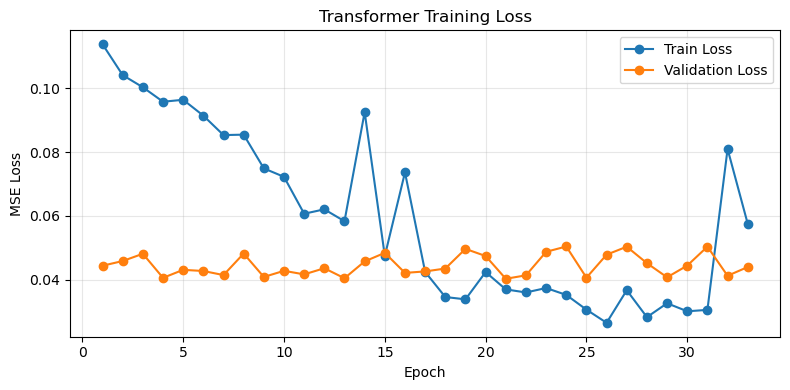

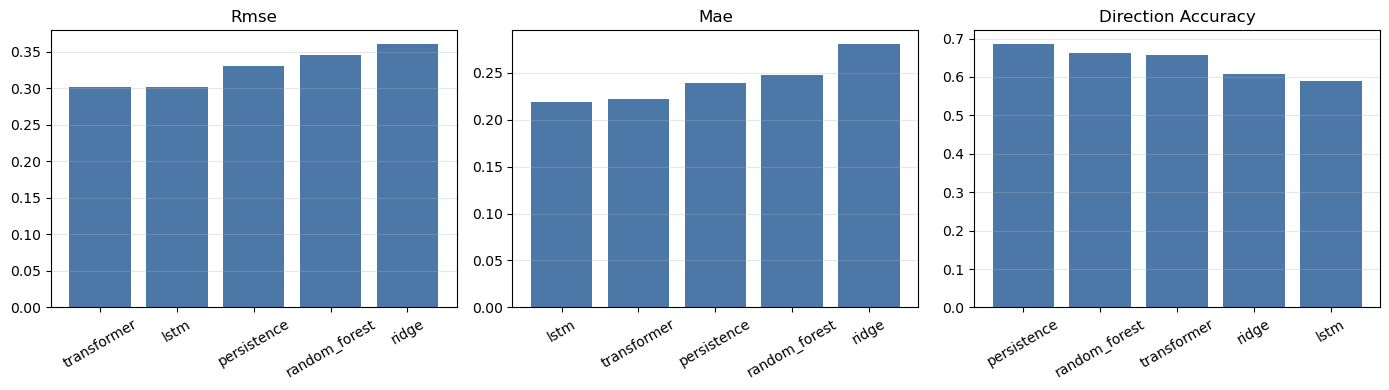

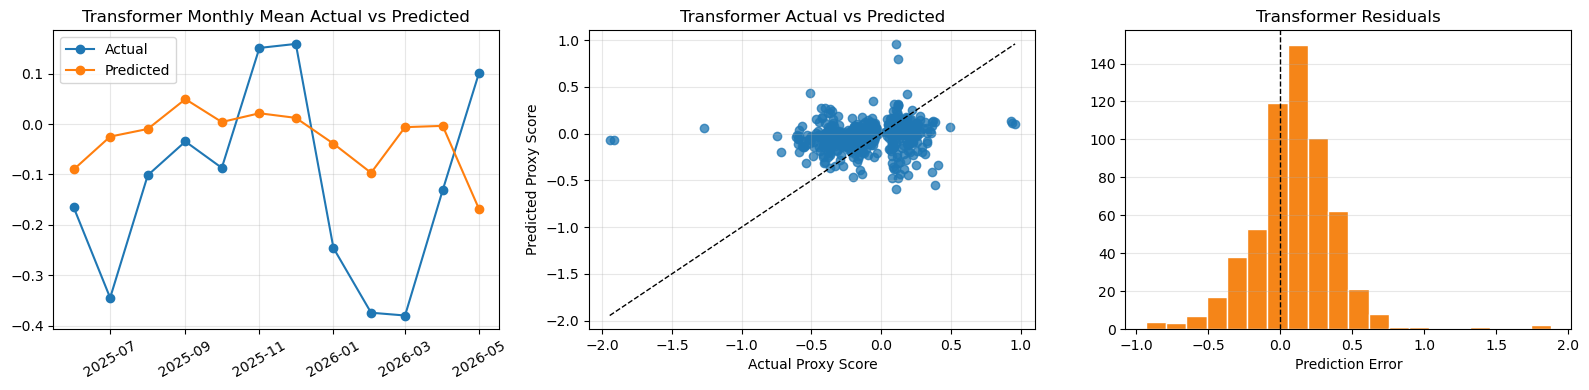

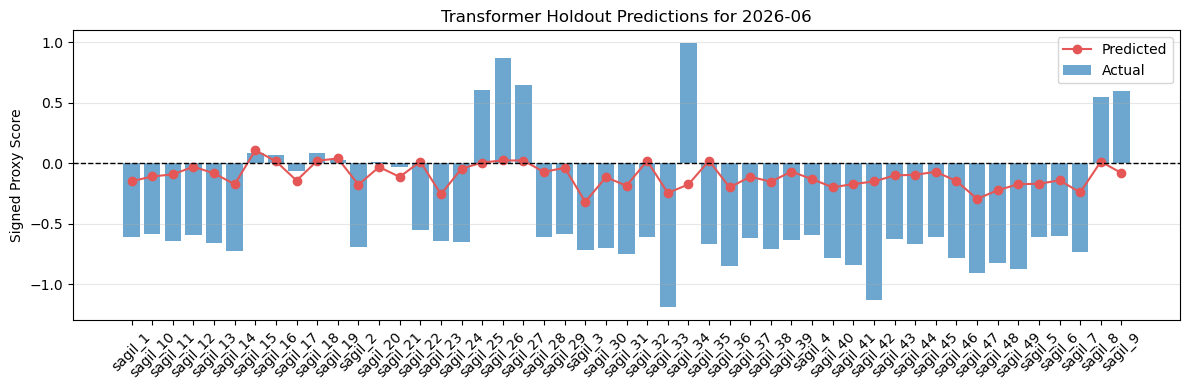

In [6]:
import matplotlib.pyplot as plt


def plot_transformer_history(history):
    if history.empty:
        print("No Transformer training history available for plotting.")
        return
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.plot(history["epoch"], history["train_loss"], marker="o", label="Train Loss")
    axis.plot(history["epoch"], history["valid_loss"], marker="o", label="Validation Loss")
    axis.set_title("Transformer Training Loss")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE Loss")
    axis.legend()
    axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_metric_comparison(comparison):
    if comparison.empty:
        print("No comparison metrics available for plotting.")
        return
    metrics_to_plot = ["rmse", "mae", "direction_accuracy"]
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
    for axis, metric in zip(axes, metrics_to_plot):
        sorted_table = comparison.sort_values(metric, ascending=(metric != "direction_accuracy"))
        axis.bar(sorted_table["model"], sorted_table[metric], color="#4C78A8")
        axis.set_title(metric.replace("_", " ").title())
        axis.tick_params(axis="x", rotation=30)
        axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_transformer_predictions(predictions):
    if predictions.empty:
        print("No Transformer predictions available for plotting.")
        return
    working = predictions.copy()
    working["target_month"] = pd.to_datetime(working["target_month"])
    working["error"] = working["predicted_proxy_score"] - working["actual_proxy_score"]
    working = working.sort_values(["target_month", "sample_id"])
    monthly = working.groupby("target_month", as_index=False)[["actual_proxy_score", "predicted_proxy_score"]].mean()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(monthly["target_month"], monthly["actual_proxy_score"], marker="o", label="Actual")
    axes[0].plot(monthly["target_month"], monthly["predicted_proxy_score"], marker="o", label="Predicted")
    axes[0].set_title("Transformer Monthly Mean Actual vs Predicted")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(working["actual_proxy_score"], working["predicted_proxy_score"], alpha=0.75)
    lower = min(working["actual_proxy_score"].min(), working["predicted_proxy_score"].min())
    upper = max(working["actual_proxy_score"].max(), working["predicted_proxy_score"].max())
    axes[1].plot([lower, upper], [lower, upper], linestyle="--", color="black", linewidth=1)
    axes[1].set_title("Transformer Actual vs Predicted")
    axes[1].set_xlabel("Actual Proxy Score")
    axes[1].set_ylabel("Predicted Proxy Score")
    axes[1].grid(alpha=0.3)

    axes[2].hist(working["error"], bins=20, color="#F58518", edgecolor="white")
    axes[2].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[2].set_title("Transformer Residuals")
    axes[2].set_xlabel("Prediction Error")
    axes[2].grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_transformer_holdout(holdout_predictions):
    if holdout_predictions.empty:
        print("No Transformer holdout predictions available for plotting.")
        return
    x_labels = holdout_predictions["sample_id"].astype(str)
    fig, axis = plt.subplots(figsize=(12, 4))
    axis.bar(x_labels, holdout_predictions["actual_proxy_score"], alpha=0.65, label="Actual")
    axis.plot(x_labels, holdout_predictions["predicted_proxy_score"], marker="o", color="#E45756", label="Predicted")
    axis.axhline(0, linestyle="--", color="black", linewidth=1)
    axis.set_title("Transformer Holdout Predictions for 2026-06")
    axis.set_ylabel("Signed Proxy Score")
    axis.tick_params(axis="x", rotation=45)
    axis.legend()
    axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_transformer_history(transformer_history)
plot_metric_comparison(comparison)
plot_transformer_predictions(transformer_test_predictions)
plot_transformer_holdout(transformer_holdout_predictions)
